# Baseline Yield Forecast Model — Punjab Kharif Rice

**Design**
| Split | Years | Rows (~22 districts) |
|---|---|---|
| Train | 2013–2022 | ~220 |
| Test | 2023 | ~22 |

**Covariates:** ERA5 monthly (Jun–Sep) → pivoted wide → one row per district × year  
**Target:** Rice yield (kg/ha) from DES district data  
**Models:** Ridge regression (primary baseline), Random Forest (second baseline)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.pipeline import Pipeline

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


## 1. Load ERA5 features & pivot to wide format

Each row in the exported CSV is one district × year × month.  
We pivot so each district-year becomes one row with columns like `tp_mm_may`, `tp_mm_jun`, …

In [2]:
era5 = pd.read_csv('data/era5_kharif_features_punjab.csv')

MONTH_NAMES = {6:'jun', 7:'jul', 8:'aug', 9:'sep'}  # June–September only
ERA5_VARS   = ['tp_mm', 'pev_mm', 't2m_c', 'swvl1', 'lai_lv']

era5_filtered = era5[era5['month'].isin(MONTH_NAMES)].copy()
era5_filtered['month_name'] = era5_filtered['month'].map(MONTH_NAMES)

era5_wide = era5_filtered.pivot_table(
    index=['district', 'year'],
    columns='month_name',
    values=ERA5_VARS
)
era5_wide.columns = [f'{var}_{mon}' for var, mon in era5_wide.columns]
era5_wide = era5_wide.reset_index()

print(f"ERA5 wide shape: {era5_wide.shape}")
print(f"Features ({len(era5_wide.columns)-2}):", list(era5_wide.columns[2:]))
era5_wide.head(3)

ERA5 wide shape: (264, 22)
Features (20): ['lai_lv_aug', 'lai_lv_jul', 'lai_lv_jun', 'lai_lv_sep', 'pev_mm_aug', 'pev_mm_jul', 'pev_mm_jun', 'pev_mm_sep', 'swvl1_aug', 'swvl1_jul', 'swvl1_jun', 'swvl1_sep', 't2m_c_aug', 't2m_c_jul', 't2m_c_jun', 't2m_c_sep', 'tp_mm_aug', 'tp_mm_jul', 'tp_mm_jun', 'tp_mm_sep']


,district,year,lai_lv_aug,lai_lv_jul,lai_lv_jun,lai_lv_sep,pev_mm_aug,pev_mm_jul,pev_mm_jun,pev_mm_sep,...,swvl1_jun,swvl1_sep,t2m_c_aug,t2m_c_jul,t2m_c_jun,t2m_c_sep,tp_mm_aug,tp_mm_jul,tp_mm_jun,tp_mm_sep
0,Amritsar,2013,1.922424,1.567261,1.046631,1.602356,-3.604520,-5.356070,-7.401492,-4.648402,...,0.254484,0.257282,29.030664,31.056543,32.516504,28.319971,8.710861,4.320145,7.355690,1.537323
1,Amritsar,2014,1.922424,1.567261,1.046631,1.602356,-5.296431,-5.679466,-9.284884,-4.069932,...,0.168264,0.297941,30.164209,30.925195,34.414453,27.888086,2.862930,6.880760,1.931190,7.599831
2,Amritsar,2015,1.922424,1.567261,1.046631,1.602356,-4.305154,-4.738506,-7.829323,-4.979435,...,0.211767,0.245977,29.767480,30.007227,31.228662,28.395654,5.517006,8.003235,2.300262,2.222061


## 2. Load yield data

Load all available DES CSVs, extract Punjab Kharif rice, and combine.  
**The `year` column is the kharif harvest year** (e.g. season "2023-24" → year 2023),  
which aligns with the ERA5 `year` column (May–Nov 2023).

In [3]:
import glob, re

def load_des_csv(path):
    df = pd.read_csv(path, encoding='utf-8-sig')

    rice = df[
        (df['State'] == 'Punjab') &
        (df['Season'] == 'Kharif') &
        (df['Crop'] == 'Rice')
    ].copy()

    # Find all Yield columns — one file may have multiple (e.g. Yield-2013-14, Yield-2014-15, ...)
    yield_cols = [c for c in df.columns if c.startswith('Yield-')]

    rows = []
    for col in yield_cols:
        year = int(re.search(r'Yield-(\d{4})', col).group(1))
        sub = rice[['District', col]].copy()
        sub.columns = ['district', 'rice_yield_kg_ha']
        sub['rice_yield_kg_ha'] = pd.to_numeric(sub['rice_yield_kg_ha'], errors='coerce')
        sub['year'] = year
        rows.append(sub)

    return pd.concat(rows, ignore_index=True)

# Use only the multi-year files (contain "-to-") to avoid duplicating 2023/2024
des_files = sorted(glob.glob('data/DES-District-Data-For-*-to-*.csv'))
print(f"Found {len(des_files)} multi-year DES file(s):")
for f in des_files:
    print(f"  {f.split('/')[-1]}")

yield_df = pd.concat([load_des_csv(f) for f in des_files], ignore_index=True)

# Normalise district names
yield_df['district'] = yield_df['district'].str.strip().str.title()
name_map = {'Ferozepur': 'Firozpur', 'S.A.S Nagar': 'Sas Nagar (Sahibzada Ajit Singh Nagar)'}
yield_df['district'] = yield_df['district'].replace(name_map)
yield_df = yield_df.dropna(subset=['rice_yield_kg_ha'])

print(f"\nYield data shape: {yield_df.shape}")
print(f"Years available: {sorted(yield_df['year'].unique())}")
yield_df.head()

Found 4 multi-year DES file(s):
  DES-District-Data-For-2013-14-to-2015-16.csv
  DES-District-Data-For-2016-17-to-2018-19.csv
  DES-District-Data-For-2019-20-to-2021-22.csv
  DES-District-Data-For-2022-23-to-2024-25.csv

Yield data shape: (268, 3)
Years available: [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


,district,rice_yield_kg_ha,year
0,Amritsar,2846.0,2013
1,Barnala,4673.0,2013
2,Bathinda,4514.0,2013
3,Faridkot,4260.0,2013
4,Fatehgarh Sahib,4081.0,2013


## 3. Join ERA5 features with yield

Inner join on `district × year`. Rows with missing yield or any missing ERA5 feature are dropped.

In [4]:
panel = era5_wide.merge(yield_df, on=['district', 'year'], how='inner')
panel = panel.dropna()

FEATURE_COLS = [c for c in panel.columns if c not in ('district', 'year', 'rice_yield_kg_ha')]

print(f"Panel shape: {panel.shape}")
print(f"Years in panel: {sorted(panel['year'].unique())}")
print(f"Districts: {panel['district'].nunique()}")
print(f"Features: {len(FEATURE_COLS)}")
panel[['district', 'year', 'rice_yield_kg_ha']].head()

Panel shape: (264, 23)
Years in panel: [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
Districts: 22
Features: 20


,district,year,rice_yield_kg_ha
0,Amritsar,2013,2846.0
1,Amritsar,2014,2775.0
2,Amritsar,2015,2834.0
3,Amritsar,2016,3189.0
4,Amritsar,2017,3761.0


## 4. Temporal train / test split

Strict temporal hold-out: train on all years < 2023, test on 2023.  
This prevents any future-leakage — the model never sees 2023 data during fit.

In [ ]:
TEST_YEAR = 2023

train = panel[panel['year'] < TEST_YEAR]
test  = panel[panel['year'] == TEST_YEAR]

X_train = train[FEATURE_COLS].values
y_train = train['rice_yield_kg_ha'].values

X_test  = test[FEATURE_COLS].values
y_test  = test['rice_yield_kg_ha'].values

print(f"Train: {X_train.shape[0]} rows ({train['year'].min()}–{train['year'].max()})")
print(f"Test:  {X_test.shape[0]} rows (year={TEST_YEAR})")

## 5. Fit models

### 5a. Ridge regression (primary baseline)

Ridge is the right choice here: ~35 correlated features (monthly ERA5), small-ish N. It shrinks correlated coefficients together rather than picking one arbitrarily like OLS does. `RidgeCV` selects alpha via leave-one-out CV on the training set.

In [ ]:
ridge_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  RidgeCV(alphas=np.logspace(-2, 4, 50), cv=None))
])

ridge_pipe.fit(X_train, y_train)
best_alpha = ridge_pipe.named_steps['model'].alpha_
print(f"Best alpha (LOO-CV): {best_alpha:.3f}")

y_pred_ridge_train = ridge_pipe.predict(X_train)
y_pred_ridge_test  = ridge_pipe.predict(X_test)

def eval_metrics(y_true, y_pred, label):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mae  = np.mean(np.abs(y_true - y_pred))
    print(f"{label:15s}  RMSE={rmse:7.1f} kg/ha   MAE={mae:7.1f} kg/ha   R²={r2:.3f}")
    return {'rmse': rmse, 'mae': mae, 'r2': r2}

print("\n--- Ridge Regression ---")
ridge_train_metrics = eval_metrics(y_train, y_pred_ridge_train, 'Train')
ridge_test_metrics  = eval_metrics(y_test,  y_pred_ridge_test,  f'Test ({TEST_YEAR})')

### 5b. Random Forest (second baseline)

In [ ]:
rf = RandomForestRegressor(n_estimators=500, max_features='sqrt', random_state=42)
rf.fit(X_train, y_train)

y_pred_rf_train = rf.predict(X_train)
y_pred_rf_test  = rf.predict(X_test)

print("--- Random Forest ---")
rf_train_metrics = eval_metrics(y_train, y_pred_rf_train, 'Train')
rf_test_metrics  = eval_metrics(y_test,  y_pred_rf_test,  f'Test ({TEST_YEAR})')

## 6. Evaluate: predicted vs actual (2023 test set)

In [ ]:
results = test[['district', 'year', 'rice_yield_kg_ha']].copy()
results['ridge_pred'] = y_pred_ridge_test
results['rf_pred']    = y_pred_rf_test
results['ridge_err']  = results['ridge_pred'] - results['rice_yield_kg_ha']
results['rf_err']     = results['rf_pred']    - results['rice_yield_kg_ha']
results = results.sort_values('rice_yield_kg_ha')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, pred_col, title in zip(axes, ['ridge_pred', 'rf_pred'], ['Ridge', 'Random Forest']):
    ax.scatter(results['rice_yield_kg_ha'], results[pred_col], alpha=0.7, edgecolors='k', linewidths=0.5)
    lims = [results[['rice_yield_kg_ha', pred_col]].min().min() - 100,
            results[['rice_yield_kg_ha', pred_col]].max().max() + 100]
    ax.plot(lims, lims, 'r--', linewidth=1.2, label='1:1 line')
    for _, row in results.iterrows():
        ax.annotate(row['district'][:6], (row['rice_yield_kg_ha'], row[pred_col]),
                    fontsize=6, alpha=0.6)
    rmse = np.sqrt(mean_squared_error(results['rice_yield_kg_ha'], results[pred_col]))
    r2   = r2_score(results['rice_yield_kg_ha'], results[pred_col])
    ax.set_title(f'{title} — Test {TEST_YEAR}\nRMSE={rmse:.0f} kg/ha  R²={r2:.3f}')
    ax.set_xlabel('Actual yield (kg/ha)')
    ax.set_ylabel('Predicted yield (kg/ha)')
    ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(results))
w = 0.35
ax.bar(x - w/2, results['ridge_err'], width=w, label='Ridge error', alpha=0.8)
ax.bar(x + w/2, results['rf_err'],    width=w, label='RF error',    alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(results['district'].str[:10], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Predicted − Actual (kg/ha)')
ax.set_title(f'Per-district prediction error — Test {TEST_YEAR}')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Ridge feature importance

Which monthly ERA5 variables drive the predictions most? The Ridge coefficients (after StandardScaler) are directly comparable across features.

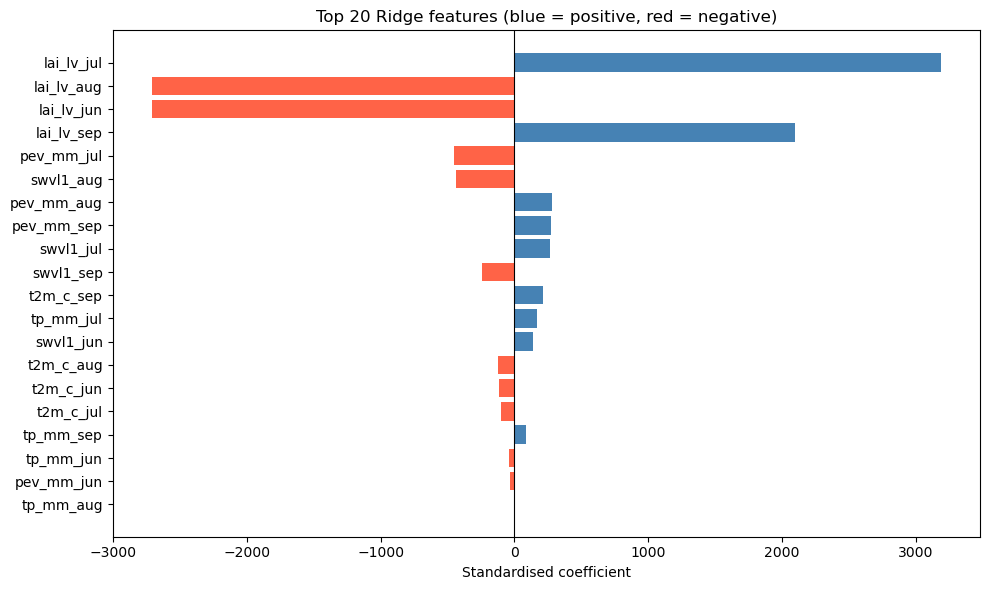

,feature,coefficient
1,lai_lv_jul,3186.546466
0,lai_lv_aug,-2709.409592
2,lai_lv_jun,-2706.681945
3,lai_lv_sep,2098.294661
5,pev_mm_jul,-451.739802
8,swvl1_aug,-438.048665
4,pev_mm_aug,283.786391
7,pev_mm_sep,273.242225
9,swvl1_jul,265.767782
11,swvl1_sep,-238.942132


In [10]:
coef_df = pd.DataFrame({
    'feature': FEATURE_COLS,
    'coefficient': ridge_pipe.named_steps['model'].coef_
}).sort_values('coefficient', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['steelblue' if c > 0 else 'tomato' for c in coef_df['coefficient'].head(20)]
ax.barh(coef_df['feature'].head(20), coef_df['coefficient'].head(20), color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Standardised coefficient')
ax.set_title('Top 20 Ridge features (blue = positive, red = negative)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

coef_df.head(20)

## 8. Summary table

In [11]:
summary = pd.DataFrame([
    {'Model': 'Ridge',         'Split': 'Train', **ridge_train_metrics},
    {'Model': 'Ridge',         'Split': 'Test',  **ridge_test_metrics},
    {'Model': 'RandomForest',  'Split': 'Train', **rf_train_metrics},
    {'Model': 'RandomForest',  'Split': 'Test',  **rf_test_metrics},
]).round(1)
summary

,Model,Split,rmse,mae,r2
0,Ridge,Train,339.0,267.5,0.7
1,Ridge,Test,424.5,386.3,0.4
2,RandomForest,Train,132.9,102.7,1.0
3,RandomForest,Test,428.1,392.9,0.4
